# Predictia impactului calitatii aerului asupra sanatatii - problema de regresie

Acest notebook prezinta rezolvarea unei probleme de regresie folosind un dataset despre calitatea aerului si impactul acesteia asupra sanatatii.

Scopul este de a construi, compara si interpreta mai multe modele de machine learning care pot prezice valoarea `HealthImpactScore`.

# 1. Definirea problemei - regresie

In acest notebook este analizata o problema de regresie folosind un dataset despre calitatea aerului si impactul acestuia asupra sanatatii.

Scopul este sa construim modele de machine learning care pot prezice valoarea `HealthImpactScore`, pe baza unor factori precum nivelul poluantilor, conditiile meteorologice si numarul de cazuri medicale asociate.

Aceasta este o problema de regresie deoarece variabila tinta este numerica.

Variabila tinta:
- `HealthImpactScore` - scor numeric care descrie impactul estimat asupra sanatatii.

Variabile de intrare:

- `AQI` - indicele general al calitatii aerului; valori mai mari indica aer mai poluat.
- `PM10` - particule in suspensie cu diametrul mai mic de 10 micrometri; pot afecta sistemul respirator.
- `PM2_5` - particule fine cu diametrul mai mic de 2.5 micrometri; sunt mai periculoase deoarece pot patrunde adanc in plamani.
- `NO2` - dioxid de azot; poluant produs in special de trafic si arderi.
- `SO2` - dioxid de sulf; poluant asociat cu arderea combustibililor fosili.
- `O3` - ozon la nivelul solului; poate irita caile respiratorii.
- `Temperature` - temperatura aerului; poate influenta nivelul si dispersia poluantilor.
- `Humidity` - umiditatea aerului; poate influenta calitatea aerului si confortul respirator.
- `WindSpeed` - viteza vantului; vantul poate dispersa sau reduce concentratia poluantilor.
- `RespiratoryCases` - numarul de cazuri respiratorii raportate.
- `CardiovascularCases` - numarul de cazuri cardiovasculare raportate.
- `HospitalAdmissions` - numarul de internari in spital asociate problemelor de sanatate.

Am ales aceasta problema deoarece poluarea aerului are un impact real asupra sanatatii populatiei, iar un model de regresie poate ajuta la estimarea riscului asupra sanatatii in functie de conditiile de mediu.

# 2. Incarcarea bibliotecilor si a dataset-ului

In aceasta etapa importam bibliotecile necesare si incarcam dataset-ul.

Vom folosi:
- pandas si numpy pentru manipularea datelor
- matplotlib si seaborn pentru vizualizari
- scikit-learn pentru modelele de machine learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../CSV_data/air_quality_health_impact_data.csv")

df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


In [2]:
df.shape

(5811, 15)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage: 681.1 KB


In [4]:
df.isnull().sum()

RecordID               0
AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
HealthImpactClass      0
dtype: int64

In [5]:
df.describe()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
count,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,2906.000000,248.438476,148.654997,100.223714,102.293445,49.456838,149.312431,14.975500,54.776853,9.989177,9.974187,4.988986,2.001033,93.785223,0.281191
std,1677.635538,144.777638,85.698500,58.096612,57.713175,28.530329,86.534240,14.483067,26.020786,5.776950,3.129234,2.216791,1.398794,13.318904,0.714075
min,1.000000,0.005817,0.015848,0.031549,0.009625,0.011023,0.001661,-9.990998,10.001506,0.002094,1.000000,0.000000,0.000000,22.448488,0.000000
25%,1453.500000,122.951293,75.374954,49.435171,53.538538,24.887264,73.999665,2.481500,31.995262,4.952343,8.000000,3.000000,1.000000,98.203057,0.000000
50%,2906.000000,249.127841,147.634997,100.506337,102.987736,49.530165,149.559871,14.942428,54.543904,10.051742,10.000000,5.000000,2.000000,100.000000,0.000000
75%,4358.500000,373.630668,222.436759,151.340260,151.658516,73.346617,223.380126,27.465374,77.641639,14.971840,12.000000,6.000000,3.000000,100.000000,0.000000
max,5811.000000,499.858837,299.901962,199.984965,199.980195,99.969561,299.936812,39.963434,99.997493,19.999139,23.000000,14.000000,12.000000,100.000000,4.000000


## Observatii initiale asupra dataset-ului

Dataset-ul contine informatii despre calitatea aerului, poluanti, conditii meteorologice si indicatori medicali.

Variabila tinta pentru regresie este `HealthImpactScore`.

Coloana `RecordID` nu va fi folosita deoarece este doar un identificator.

Coloana `HealthImpactClass` nu va fi folosita deoarece este o variabila de clasificare si poate introduce informatie nedorita in problema de regresie.

# 3. Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa realizam analiza exploratorie a datelor.

Scopul este sa intelegem:
- distributia variabilei tinta
- distributia variabilelor numerice
- existenta valorilor extreme
- relatiile dintre variabile
- corelatiile dintre variabile
- legatura dintre poluanti si impactul asupra sanatatii

## 3.1 Distributia variabilei tinta

In aceasta sectiune analizam distributia variabilei `HealthImpactScore`.

Aceasta este variabila pe care dorim sa o prezicem.

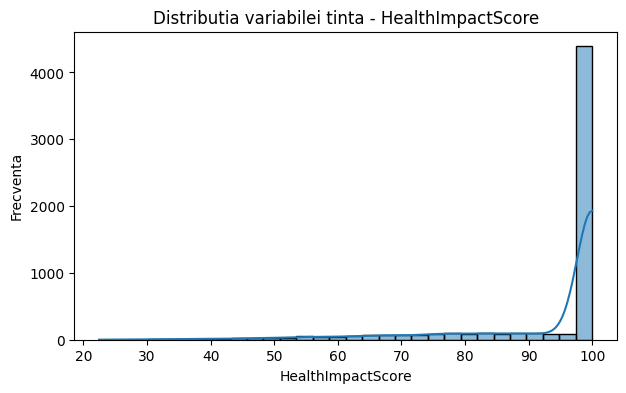

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df["HealthImpactScore"], bins=30, kde=True)
plt.title("Distributia variabilei tinta - HealthImpactScore")
plt.xlabel("HealthImpactScore")
plt.ylabel("Frecventa")
plt.show()

Se observa distributia scorului de impact asupra sanatatii.

Daca valorile sunt concentrate intr-un anumit interval, modelul poate avea dificultati in a diferentia intre observatii apropiate.

Aceasta analiza este importanta deoarece ne ajuta sa intelegem comportamentul variabilei tinta inainte de antrenarea modelelor.

## 3.2 Distributia variabilelor numerice

Analizam distributiile tuturor variabilelor numerice pentru a observa cum sunt raspandite valorile.

Aceasta etapa ajuta la identificarea unor posibile valori extreme sau distributii dezechilibrate.

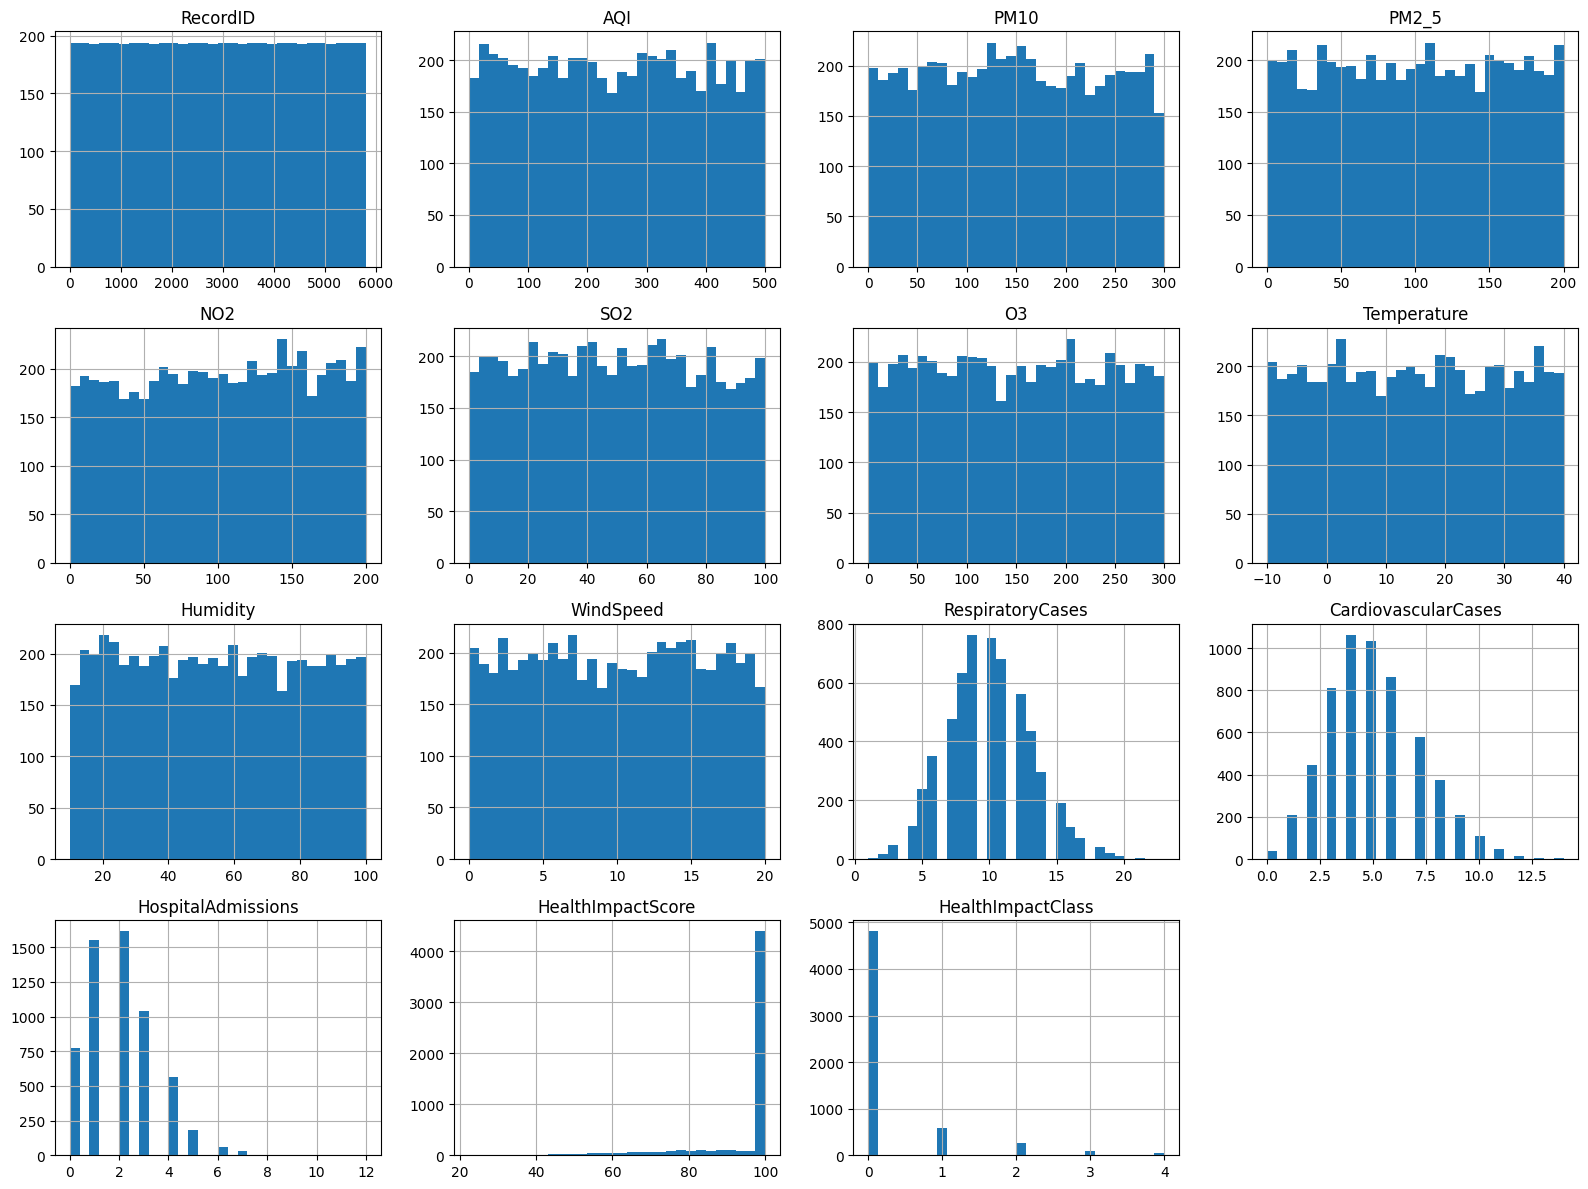

In [7]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(16,12), bins=30)
plt.tight_layout()
plt.show()

Variabilele numerice au distributii diferite.

Poluantii precum `AQI`, `PM10`, `PM2_5`, `NO2`, `SO2` si `O3` descriu nivelul poluarii aerului.

Variabilele meteorologice precum `Temperature`, `Humidity` si `WindSpeed` pot influenta dispersia poluantilor.

Variabilele medicale precum `RespiratoryCases`, `CardiovascularCases` si `HospitalAdmissions` pot fi asociate cu impactul asupra sanatatii.

## 3.3 Analiza valorilor extreme

Pentru a observa posibile valori extreme, folosim boxplot-uri.

Valorile extreme nu sunt eliminate automat, deoarece in cazul poluarii si sanatatii pot reprezenta situatii reale importante.

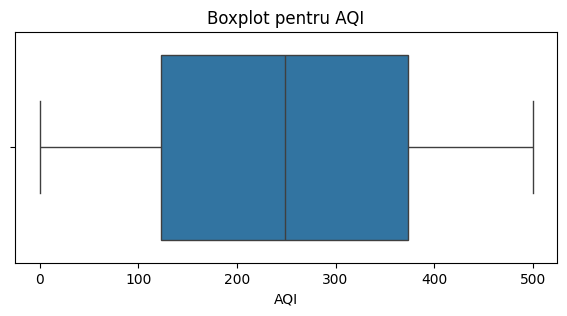

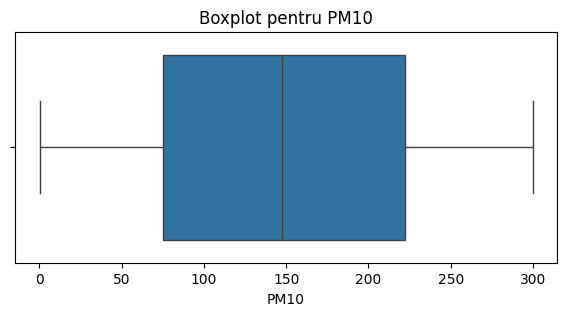

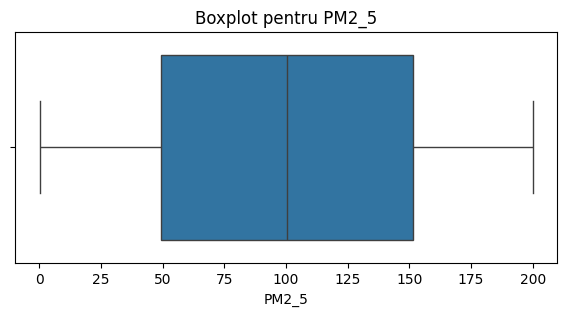

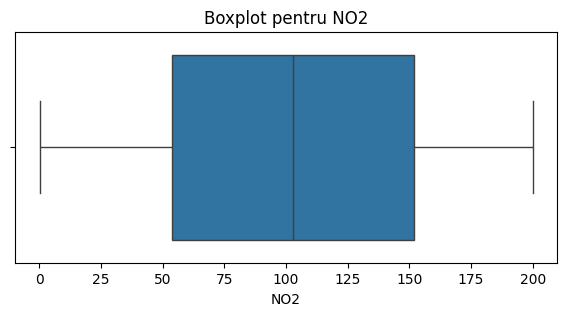

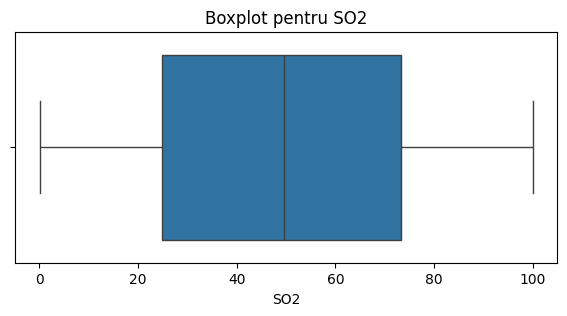

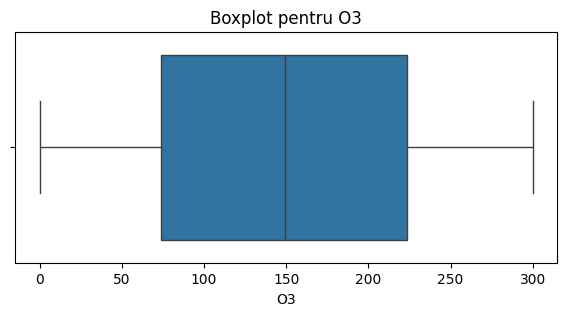

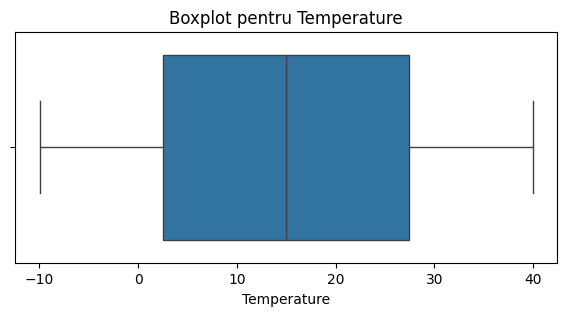

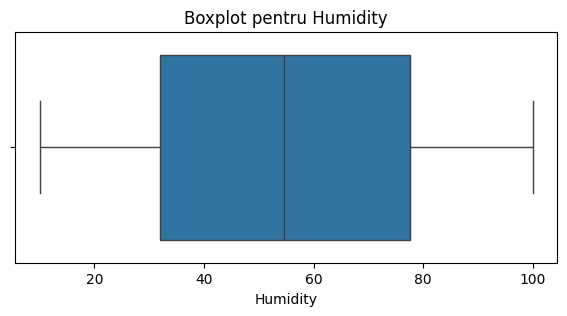

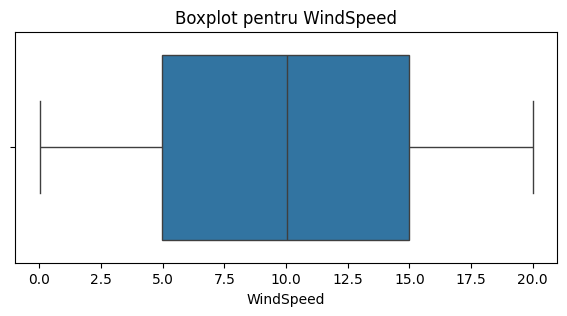

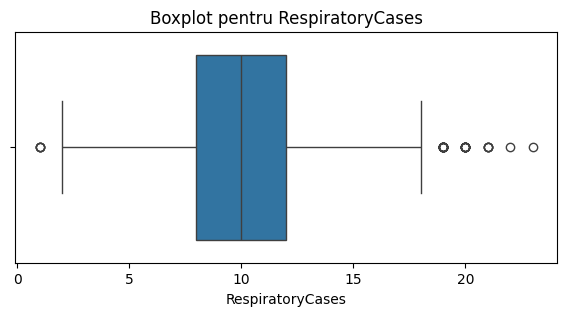

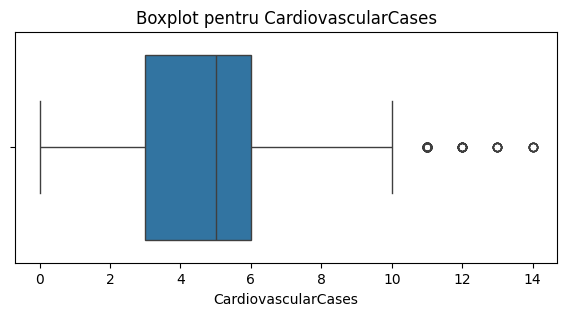

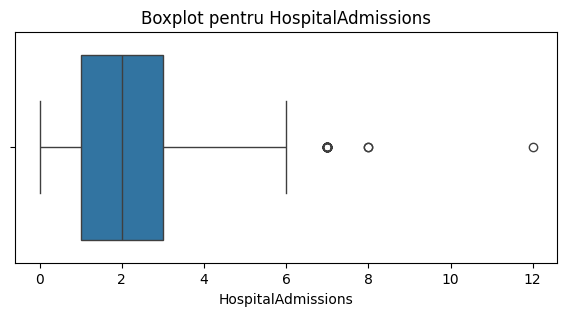

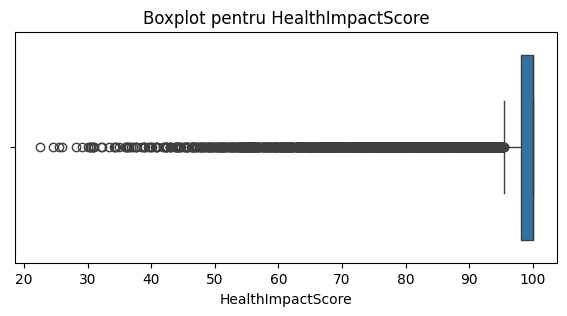

In [8]:
features_for_boxplot = [
    "AQI", "PM10", "PM2_5", "NO2", "SO2", "O3",
    "Temperature", "Humidity", "WindSpeed",
    "RespiratoryCases", "CardiovascularCases",
    "HospitalAdmissions",
    "HealthImpactScore"
]

for col in features_for_boxplot:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot pentru {col}")
    plt.show()

Boxplot-urile permit observarea valorilor aflate departe de majoritatea datelor.

In acest context, valorile extreme pot fi importante, deoarece pot indica niveluri ridicate de poluare sau un impact major asupra sanatatii.

Din acest motiv, ele sunt pastrate pentru modelare.

## 3.4 Matricea de corelatie

Matricea de corelatie arata relatiile liniare dintre variabile.

Ne intereseaza in special corelatia dintre fiecare variabila si `HealthImpactScore`.

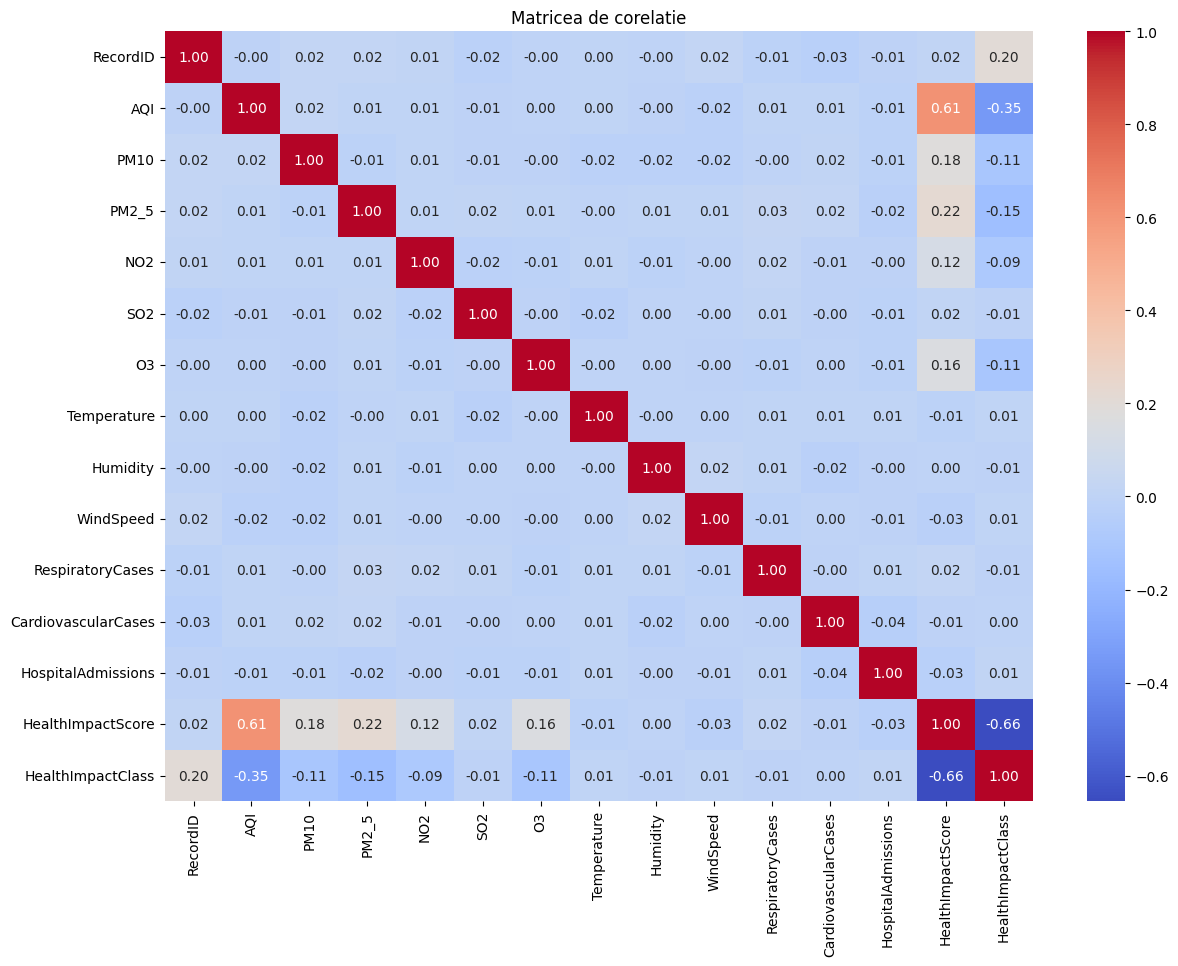

In [9]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matricea de corelatie")
plt.show()

Matricea de corelatie ajuta la identificarea variabilelor care au o relatie mai puternica cu `HealthImpactScore`.

Chiar daca unele corelatii sunt slabe, acest lucru nu inseamna ca variabilele nu sunt utile.

Modelele de machine learning pot surprinde si relatii neliniare, nu doar relatii liniare.

## 3.5 Corelatia variabilelor cu target-ul

Pentru o analiza mai clara, afisam corelatia fiecarei variabile cu `HealthImpactScore`.

In [10]:
correlations = df.corr()["HealthImpactScore"].sort_values(ascending=False)

correlations

HealthImpactScore      1.000000
AQI                    0.614560
PM2_5                  0.220347
PM10                   0.182600
O3                     0.157940
NO2                    0.124435
RespiratoryCases       0.019268
RecordID               0.015786
SO2                    0.015535
Humidity               0.000662
CardiovascularCases   -0.008857
Temperature           -0.010556
WindSpeed             -0.025447
HospitalAdmissions    -0.029304
HealthImpactClass     -0.655611
Name: HealthImpactScore, dtype: float64

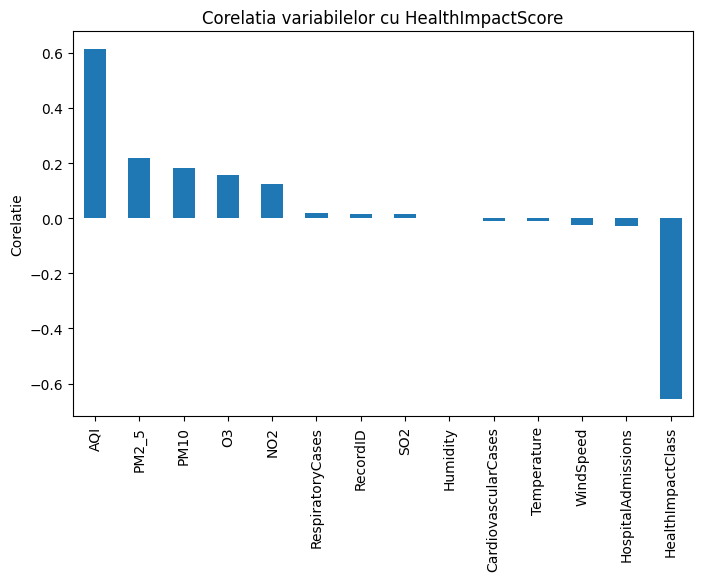

In [11]:
plt.figure(figsize=(8,5))
correlations.drop("HealthImpactScore").plot(kind="bar")
plt.title("Corelatia variabilelor cu HealthImpactScore")
plt.ylabel("Corelatie")
plt.show()

Acest grafic arata care variabile au cea mai mare legatura liniara cu `HealthImpactScore`.

Variabilele cu valori pozitive ale corelatiei tind sa creasca impreuna cu target-ul.

Variabilele cu valori negative tind sa scada atunci cand target-ul creste.

## 3.6 Relatia dintre poluanti si HealthImpactScore

In aceasta sectiune analizam vizual relatia dintre principalii poluanti si scorul de impact asupra sanatatii.

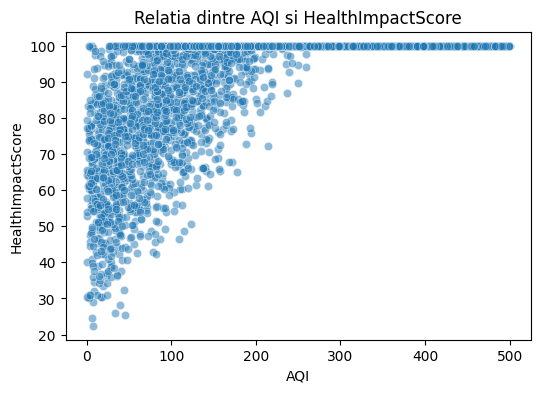

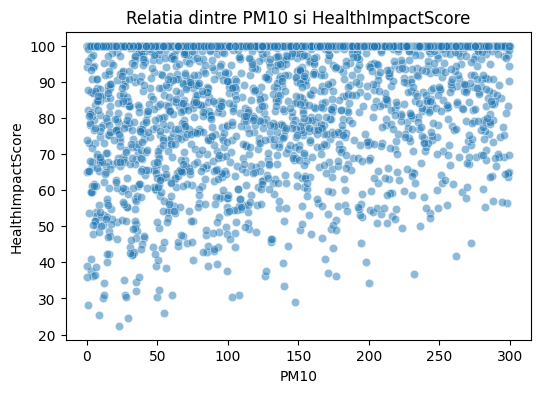

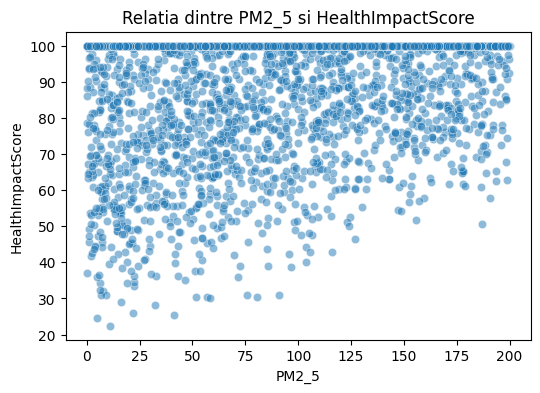

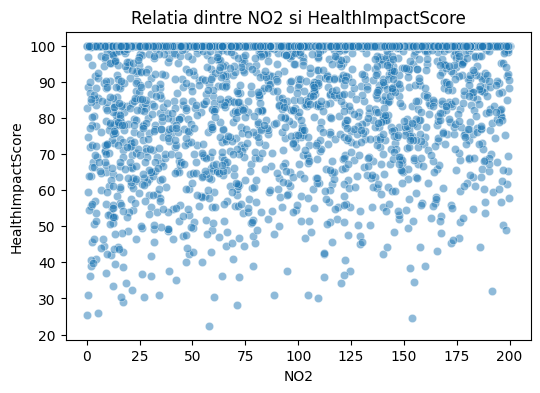

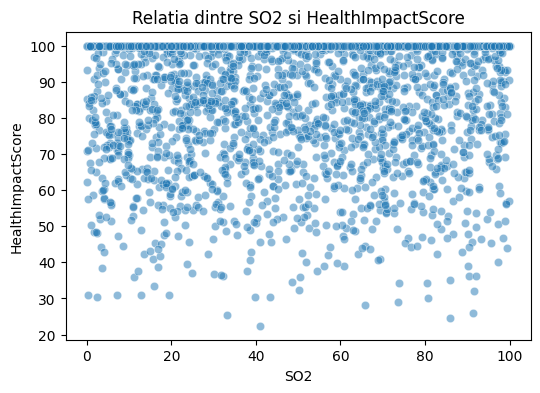

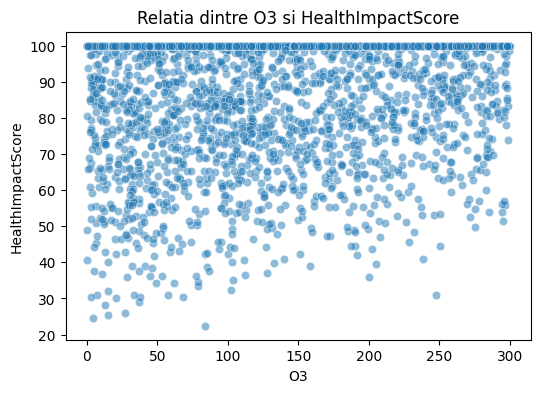

In [12]:
pollution_cols = ["AQI", "PM10", "PM2_5", "NO2", "SO2", "O3"]

for col in pollution_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["HealthImpactScore"], alpha=0.5)
    plt.title(f"Relatia dintre {col} si HealthImpactScore")
    plt.xlabel(col)
    plt.ylabel("HealthImpactScore")
    plt.show()

Scatter plot-urile arata modul in care valorile poluantilor sunt asociate cu `HealthImpactScore`.

In mod intuitiv, valori mai mari ale poluantilor pot fi asociate cu un impact mai mare asupra sanatatii.

Totusi, relatia poate fi complexa si influentata de mai multi factori in acelasi timp.

## 3.7 Relatia dintre indicatorii medicali si HealthImpactScore

Analizam relatia dintre cazurile medicale raportate si scorul de impact asupra sanatatii.

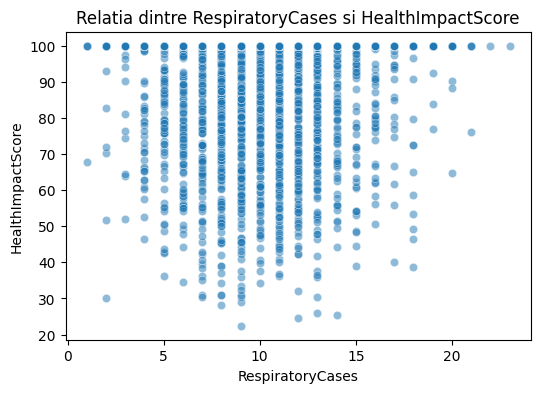

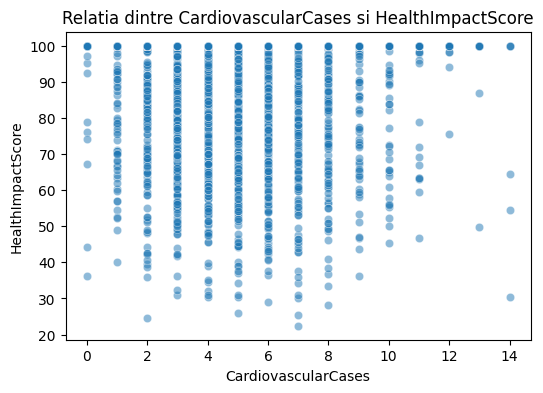

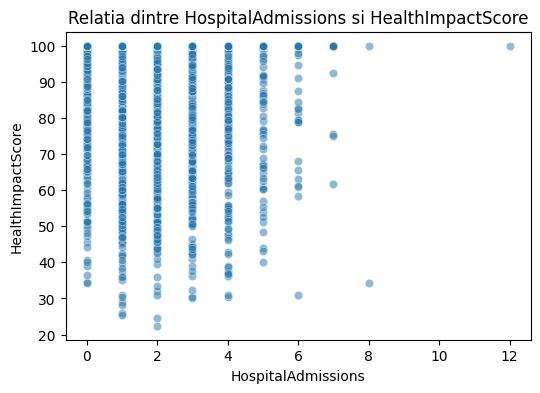

In [13]:
health_cols = ["RespiratoryCases", "CardiovascularCases", "HospitalAdmissions"]

for col in health_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["HealthImpactScore"], alpha=0.5)
    plt.title(f"Relatia dintre {col} si HealthImpactScore")
    plt.xlabel(col)
    plt.ylabel("HealthImpactScore")
    plt.show()

Indicatorii medicali sunt importanti deoarece pot reflecta efectele poluarii asupra populatiei.

Daca aceste variabile sunt asociate cu `HealthImpactScore`, ele pot ajuta modelele sa faca predictii mai bune.

# 4. Preprocesarea datelor

In aceasta etapa pregatim datele pentru modelele de regresie.

Deoarece toate variabilele sunt numerice, nu este necesar One-Hot Encoding.

Totusi, eliminam coloanele care nu trebuie folosite:
- `RecordID`
- `HealthImpactClass`

`RecordID` este doar un identificator.

`HealthImpactClass` este o variabila de clasificare si poate introduce informatie nedorita in problema de regresie.

In [14]:
df_model = df.copy()

df_model = df_model.drop(["RecordID", "HealthImpactClass"], axis=1)

df_model.head()

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore
0,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041
1,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000
2,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000
3,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000
4,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643


## 4.1 Separarea variabilelor de intrare si a target-ului

Separaram dataset-ul in:
- `X`: variabilele de intrare
- `y`: variabila tinta

In [15]:
X = df_model.drop("HealthImpactScore", axis=1)
y = df_model["HealthImpactScore"]

In [16]:
X.head()

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions
0,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1
1,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0
2,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0
3,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1
4,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1


In [17]:
y.head()

0     97.244041
1    100.000000
2    100.000000
3    100.000000
4     95.182643
Name: HealthImpactScore, dtype: float64

## 4.2 Impartirea datelor in train si test

Datele sunt impartite in:
- 75% pentru antrenare
- 25% pentru testare

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

X_train.shape, X_test.shape

((4358, 12), (1453, 12))

# 5. Antrenarea si compararea modelelor de baza

In aceasta etapa antrenam mai multe modele de regresie si comparam performanta acestora.

Modelele folosite sunt:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Support Vector Regressor
- KNN Regressor
- Gaussian Process Regressor

Metricile folosite sunt:
- MSE
- MAE
- RMSE
- R2

Pentru MSE, MAE si RMSE, valori mai mici sunt mai bune.

Pentru R2, valori mai mari sunt mai bune.

## 5.1 Importarea modelelor si metricilor

Importam modelele de regresie si metricile necesare pentru evaluare.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 5.2 Functie de evaluare

Cream o functie care calculeaza automat metricile pentru fiecare model.

In [20]:
def evaluate_regression_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## 5.3 Definirea modelelor de baza

Definim modelele care vor fi antrenate.

Pentru SVR, KNN si Gaussian Process folosim StandardScaler, deoarece aceste modele sunt sensibile la scara valorilor.

In [21]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),

    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=100
    ),

    "Support Vector Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ]),

    "KNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor())
    ]),

    "Gaussian Process Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianProcessRegressor(random_state=42))
    ])
}

## 5.4 Antrenarea modelelor de baza

Antrenam fiecare model pe setul de antrenare si il evaluam pe setul de test.

Pentru Gaussian Process folosim un subset mai mic, deoarece poate fi lent pe dataset-uri mai mari.

In [22]:
results = []

for name, model in models.items():
    print(f"Antrenare model: {name}")

    if name == "Gaussian Process Regressor":
        X_train_gp = X_train.sample(800, random_state=42)
        y_train_gp = y_train.loc[X_train_gp.index]

        model.fit(X_train_gp, y_train_gp)
    else:
        model.fit(X_train, y_train)

    metrics = evaluate_regression_model(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df[["Model", "MSE", "MAE", "RMSE", "R2"]]
results_df.sort_values(by="R2", ascending=False)

Antrenare model: Linear Regression
Antrenare model: Decision Tree Regressor
Antrenare model: Random Forest Regressor
Antrenare model: Support Vector Regressor
Antrenare model: KNN Regressor
Antrenare model: Gaussian Process Regressor


,Model,MSE,MAE,RMSE,R2
2,Random Forest Regressor,9.905288,1.522831,3.147267,0.945270
1,Decision Tree Regressor,27.944684,2.334042,5.286273,0.845597
4,KNN Regressor,62.950638,4.109151,7.934144,0.652177
3,Support Vector Regressor,81.412844,4.654452,9.022907,0.550168
0,Linear Regression,90.180874,7.316040,9.496361,0.501721
5,Gaussian Process Regressor,4033.502260,59.177033,63.509860,-21.286414


## 5.5 Modele optionale: XGBoost, CatBoost si Explainable Boosting


In [23]:
optional_models = {}

try:
    from xgboost import XGBRegressor

    optional_models["XGBoost Regressor"] = XGBRegressor(
        random_state=42,
        n_estimators=100,
        objective="reg:squarederror"
    )
except:
    print("XGBoost nu este instalat.")

try:
    from catboost import CatBoostRegressor

    optional_models["CatBoost Regressor"] = CatBoostRegressor(
        random_state=42,
        verbose=0
    )
except:
    print("CatBoost nu este instalat.")

try:
    from interpret.glassbox import ExplainableBoostingRegressor

    optional_models["Explainable Boosting Regressor"] = ExplainableBoostingRegressor(
        random_state=42
    )
except:
    print("Interpret / EBM nu este instalat.")

In [24]:
optional_results = []

for name, model in optional_models.items():
    print(f"Antrenare model: {name}")

    model.fit(X_train, y_train)

    metrics = evaluate_regression_model(model, X_test, y_test)
    metrics["Model"] = name
    optional_results.append(metrics)

optional_results_df = pd.DataFrame(optional_results)

if len(optional_results_df) > 0:
    optional_results_df = optional_results_df[["Model", "MSE", "MAE", "RMSE", "R2"]]
    all_results_df = pd.concat([results_df, optional_results_df], ignore_index=True)
else:
    all_results_df = results_df.copy()

all_results_df.sort_values(by="R2", ascending=False)

Antrenare model: XGBoost Regressor
Antrenare model: CatBoost Regressor
Antrenare model: Explainable Boosting Regressor


,Model,MSE,MAE,RMSE,R2
7,CatBoost Regressor,1.793851,0.772981,1.339347,0.990088
8,Explainable Boosting Regressor,5.929415,1.670567,2.435039,0.967238
6,XGBoost Regressor,6.236557,1.251911,2.497310,0.965541
2,Random Forest Regressor,9.905288,1.522831,3.147267,0.945270
1,Decision Tree Regressor,27.944684,2.334042,5.286273,0.845597
4,KNN Regressor,62.950638,4.109151,7.934144,0.652177
3,Support Vector Regressor,81.412844,4.654452,9.022907,0.550168
0,Linear Regression,90.180874,7.316040,9.496361,0.501721
5,Gaussian Process Regressor,4033.502260,59.177033,63.509860,-21.286414


## 5.6 Interpretarea rezultatelor modelelor de baza

Dupa antrenarea modelelor de baza, se observa diferente clare intre performantele acestora.

Cel mai bun rezultat a fost obtinut de `CatBoost Regressor`, cu un R2 de aproximativ 0.99. Acest lucru indica faptul ca modelul explica foarte bine variatia variabilei tinta `HealthImpactScore`.

Modele precum `Explainable Boosting Regressor`, `XGBoost Regressor` si `Random Forest Regressor` au obtinut de asemenea rezultate foarte bune, cu valori R2 peste 0.94.

Modelele mai simple, precum `Linear Regression`, au avut performante mai slabe, ceea ce sugereaza ca relatia dintre variabilele de intrare si target nu este strict liniara.

`Gaussian Process Regressor` a avut cea mai slaba performanta, cu un R2 negativ, ceea ce inseamna ca modelul nu este potrivit pentru acest dataset in forma actuala.

In concluzie, modelele bazate pe arbori si boosting sunt cele mai potrivite pentru aceasta problema de regresie.

# 6. Selectarea celor mai bune 5 modele

Conform rezultatelor obtinute, cele mai bune 5 modele sunt alese in functie de valoarea R2.

Am ales R2 ca metrica principala deoarece aceasta arata cat de bine explica modelul variatia target-ului.

Totusi, sunt analizate si erorile MSE, MAE si RMSE, deoarece acestea arata cat de departe sunt predictiile fata de valorile reale.

In [25]:
top5_models_df = all_results_df.sort_values(by="R2", ascending=False).head(5)

top5_models_df

,Model,MSE,MAE,RMSE,R2
7,CatBoost Regressor,1.793851,0.772981,1.339347,0.990088
8,Explainable Boosting Regressor,5.929415,1.670567,2.435039,0.967238
6,XGBoost Regressor,6.236557,1.251911,2.497310,0.965541
2,Random Forest Regressor,9.905288,1.522831,3.147267,0.945270
1,Decision Tree Regressor,27.944684,2.334042,5.286273,0.845597


## 6.1 Interpretarea celor mai bune 5 modele

Cele mai bune 5 modele obtinute sunt:

1. CatBoost Regressor
2. Explainable Boosting Regressor
3. XGBoost Regressor
4. Random Forest Regressor
5. Decision Tree Regressor

Se observa ca modelele de tip boosting au obtinut cele mai bune performante.

Acest lucru sugereaza ca datele contin relatii neliniare intre variabile, iar modelele complexe reusesc sa le surprinda mai bine decat modelele liniare.

CatBoost este modelul cu cea mai buna performanta initiala, avand cel mai mare R2 si cele mai mici erori.

# 7. Ajustarea hiperparametrilor

In aceasta etapa sunt optimizate cele mai bune 5 modele obtinute anterior.

Pentru optimizare se foloseste GridSearchCV, iar metrica folosita este R2.

Scopul este de a gasi combinatii mai bune de hiperparametri si de a imbunatati performanta modelelor.

## 7.1 Tuning pentru CatBoost Regressor

CatBoost a fost cel mai bun model de baza, deci este important sa fie optimizat.

Se testeaza:
- numarul de iteratii
- adancimea arborilor
- rata de invatare

In [26]:
from sklearn.model_selection import GridSearchCV

cat_param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

grid_cat = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    cat_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_cat.fit(X_train, y_train)

print("Best params CatBoost:", grid_cat.best_params_)
print("Best score CatBoost:", grid_cat.best_score_)

Best params CatBoost: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}
Best score CatBoost: 0.9866277071474052


## 7.2 Tuning pentru Explainable Boosting Regressor

Explainable Boosting Regressor este un model performant si interpretabil.

Acesta combina performanta buna cu explicabilitatea, ceea ce il face potrivit pentru analiza impactului asupra sanatatii.

In [27]:
ebm_param_grid = {
    "max_bins": [128],
    "learning_rate": [0.05],
    "max_rounds": [500]
}

grid_ebm = GridSearchCV(
    ExplainableBoostingRegressor(random_state=42),
    ebm_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_ebm.fit(X_train, y_train)

print("Best params EBM:", grid_ebm.best_params_)
print("Best score EBM:", grid_ebm.best_score_)

Best params EBM: {'learning_rate': 0.05, 'max_bins': 128, 'max_rounds': 500}
Best score EBM: 0.9672303739853229


## 7.3 Tuning pentru XGBoost Regressor

XGBoost este un model puternic bazat pe boosting.

Acesta construieste arbori succesivi, fiecare incercand sa corecteze erorile modelului anterior.

In [28]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, objective="reg:squarederror"),
    xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best params XGB:", grid_xgb.best_params_)
print("Best score XGB:", grid_xgb.best_score_)

Best params XGB: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best score XGB: 0.9689083151534783


## 7.4 Tuning pentru Random Forest Regressor

Random Forest a avut o performanta buna in etapa de baza.

Optimizam:
- numarul de arbori
- adancimea maxima
- numarul minim de exemple necesare pentru split

In [29]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best params RF:", grid_rf.best_params_)
print("Best score RF:", grid_rf.best_score_)

Best params RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best score RF: 0.9438332627561371


## 7.5 Tuning pentru Decision Tree Regressor

Decision Tree poate invata relatii complexe, dar poate face overfitting.

De aceea, optimizam parametri care controleaza complexitatea arborelui.

In [30]:
dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best params DT:", grid_dt.best_params_)
print("Best score DT:", grid_dt.best_score_)

Best params DT: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best score DT: 0.8616054494509529


# 8. Compararea modelelor optimizate

Dupa ajustarea hiperparametrilor, modelele optimizate sunt evaluate din nou pe setul de test.

Scopul acestei etape este sa observam daca optimizarea a imbunatatit performanta fata de modelele de baza.

Modelul final va fi ales in functie de:
- R2 cat mai mare
- MSE, MAE si RMSE cat mai mici

In [31]:
tuned_models = {
    "Tuned CatBoost": grid_cat.best_estimator_,
    "Tuned EBM": grid_ebm.best_estimator_,
    "Tuned XGBoost": grid_xgb.best_estimator_,
    "Tuned Random Forest": grid_rf.best_estimator_,
    "Tuned Decision Tree": grid_dt.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    metrics = evaluate_regression_model(model, X_test, y_test)
    metrics["Model"] = name
    tuned_results.append(metrics)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df[["Model", "MSE", "MAE", "RMSE", "R2"]]
tuned_results_df.sort_values(by="R2", ascending=False)

,Model,MSE,MAE,RMSE,R2
0,Tuned CatBoost,2.425413,0.900723,1.557374,0.986599
2,Tuned XGBoost,5.150531,1.199651,2.269478,0.971542
1,Tuned EBM,5.800549,1.663454,2.408433,0.967950
3,Tuned Random Forest,9.891078,1.527988,3.145008,0.945349
4,Tuned Decision Tree,25.005392,2.259955,5.000539,0.861837


In [32]:
tuned_results = []

for name, model in tuned_models.items():
    metrics = evaluate_regression_model(model, X_test, y_test)
    metrics["Model"] = name
    tuned_results.append(metrics)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df[["Model", "MSE", "MAE", "RMSE", "R2"]]
tuned_results_df.sort_values(by="R2", ascending=False)

,Model,MSE,MAE,RMSE,R2
0,Tuned CatBoost,2.425413,0.900723,1.557374,0.986599
2,Tuned XGBoost,5.150531,1.199651,2.269478,0.971542
1,Tuned EBM,5.800549,1.663454,2.408433,0.967950
3,Tuned Random Forest,9.891078,1.527988,3.145008,0.945349
4,Tuned Decision Tree,25.005392,2.259955,5.000539,0.861837


## 8.1 Alegerea modelului final

Modelul final este ales pe baza performantelor obtinute dupa tuning.

Alegem modelul cu cel mai mare R2 si cu erori cat mai mici.

In [33]:
best_model_name = tuned_results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print("Cel mai bun model este:", best_model_name)

Cel mai bun model este: Tuned CatBoost


## 8.2 Interpretarea comparatiei finale

Dupa ajustarea hiperparametrilor, cele mai bune rezultate au fost obtinute de modelul `Tuned CatBoost`.

Acesta a obtinut:
- MSE = 2.425413
- MAE = 0.900723
- RMSE = 1.557374
- R2 = 0.986599

Valoarea R2 foarte apropiata de 1 arata ca modelul explica foarte bine variatia variabilei tinta `HealthImpactScore`.

Comparativ cu celelalte modele, CatBoost are cele mai mici erori si cel mai bun scor R2.

XGBoost si Explainable Boosting Regressor au obtinut de asemenea rezultate foarte bune, dar CatBoost ramane cel mai performant model dupa tuning.

Random Forest a avut o performanta buna, insa mai slaba decat modelele de boosting.

Decision Tree a obtinut cel mai slab rezultat dintre modelele optimizate, ceea ce poate indica faptul ca un singur arbore nu este suficient pentru a surprinde relatiile complexe din date.

In concluzie, modelele bazate pe boosting sunt cele mai potrivite pentru aceasta problema de regresie.

## 8.3 Alegerea modelului final

Modelul final ales pentru analiza urmatoare este `Tuned CatBoost`.

Acesta a fost ales deoarece are cel mai mare scor R2 si cele mai mici erori dintre toate modelele optimizate.

Modelul va fi folosit in continuare pentru:
- analiza predictiilor
- analiza erorilor
- curbele de invatare
- explicabilitate folosind SHAP

In [34]:
best_model_name = "Tuned CatBoost"
best_model = grid_cat.best_estimator_

print("Cel mai bun model este:", best_model_name)

Cel mai bun model este: Tuned CatBoost


# 9. Analiza predictiilor

In aceasta etapa analizam predictiile facute de modelul final.

Comparam valorile reale ale variabilei `HealthImpactScore` cu valorile prezise de modelul `Tuned CatBoost`.

Aceasta analiza ne ajuta sa vedem cat de apropiate sunt predictiile modelului de valorile reale.

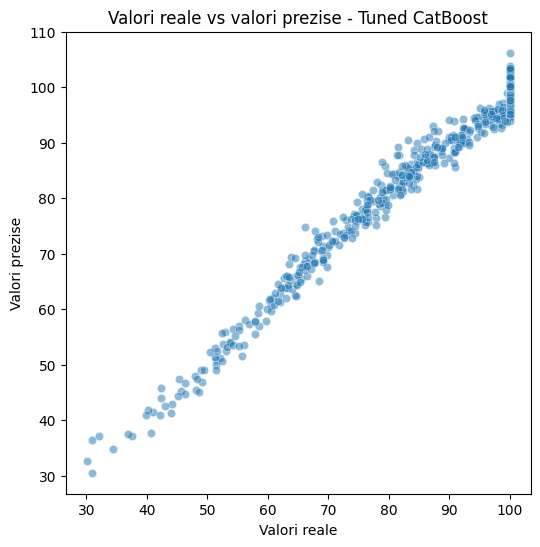

In [35]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5)
plt.xlabel("Valori reale")
plt.ylabel("Valori prezise")
plt.title("Valori reale vs valori prezise - Tuned CatBoost")
plt.show()

## 9.1 Interpretarea graficului valori reale vs valori prezise

Daca modelul prezice bine, punctele trebuie sa fie cat mai apropiate de diagonala imaginara a graficului.

In cazul modelului Tuned CatBoost, predictiile sunt foarte apropiate de valorile reale, ceea ce confirma performanta buna observata prin metricile R2, MAE, MSE si RMSE.

Acest lucru arata ca modelul reuseste sa estimeze corect scorul `HealthImpactScore` pentru majoritatea observatiilor din setul de test.

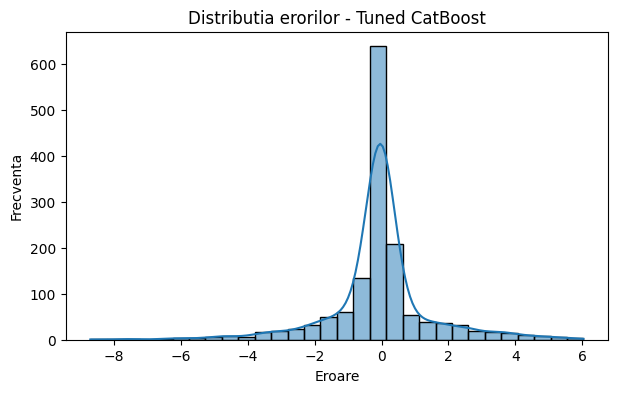

In [36]:
residuals = y_test - y_pred_best

plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distributia erorilor - Tuned CatBoost")
plt.xlabel("Eroare")
plt.ylabel("Frecventa")
plt.show()

Distributia erorilor arata diferenta dintre valorile reale si valorile prezise.

Pentru modelul Tuned CatBoost, erorile sunt relativ mici, lucru confirmat si de valorile MAE si RMSE.

Acest rezultat sugereaza ca modelul are o capacitate buna de generalizare pe date noi.

# 10. Curbele de invatare

Curbele de invatare sunt folosite pentru a analiza comportamentul modelelor in functie de dimensiunea setului de antrenare.

Acestea ajuta la identificarea situatiilor de:
- overfitting
- underfitting
- generalizare buna

In [37]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_mean, label="Train score")
    plt.plot(train_sizes, val_mean, label="Validation score")
    plt.xlabel("Training size")
    plt.ylabel("R2 score")
    plt.title(title)
    plt.legend()
    plt.show()

## 10.1 Curbele de invatare pentru modelele optimizate

Afisam curbele de invatare pentru modelele optimizate.

Daca scorul de antrenare este mult mai mare decat scorul de validare, modelul poate avea overfitting.

Daca ambele scoruri sunt mici, modelul poate avea underfitting.

Daca cele doua scoruri sunt apropiate si bune, modelul generalizeaza bine.

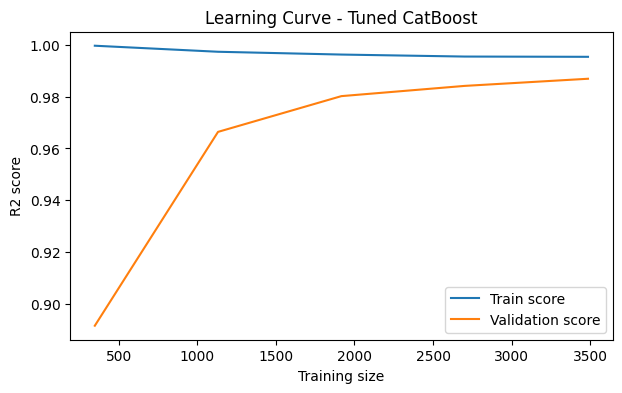

In [ ]:
for name, model in tuned_models.items():
    plot_learning_curve(model, X_train, y_train, f"Learning Curve - {name}")

Pe baza curbelor de invatare se poate observa daca modelele invata stabil si daca performanta de validare se apropie de performanta de antrenare.

Aceasta etapa este importanta pentru a intelege daca modelele generalizeaza sau doar memoreaza datele.

# 11. Explicabilitatea modelului folosind SHAP

Pentru a intelege modul in care modelul Tuned CatBoost face predictii, folosim biblioteca SHAP.

SHAP ne ajuta sa vedem ce caracteristici influenteaza cel mai mult valoarea prezisa pentru `HealthImpactScore`.

Analiza SHAP include:
- summary plot
- bar plot
- waterfall plot
- scatter plot pentru caracteristici relevante

In [ ]:
import shap

## 11.1 Pregatirea datelor pentru SHAP

Pentru SHAP folosim un subset al datelor, deoarece calculul poate fi mai lent.

Acest lucru este acceptabil deoarece scopul este interpretarea comportamentului modelului, nu reantrenarea acestuia.

In [ ]:
X_shap = X_test.sample(200, random_state=42)

## 11.2 Summary plot si bar plot

Summary plot-ul arata influenta caracteristicilor asupra predictiilor.

Bar plot-ul arata importanta medie a caracteristicilor.

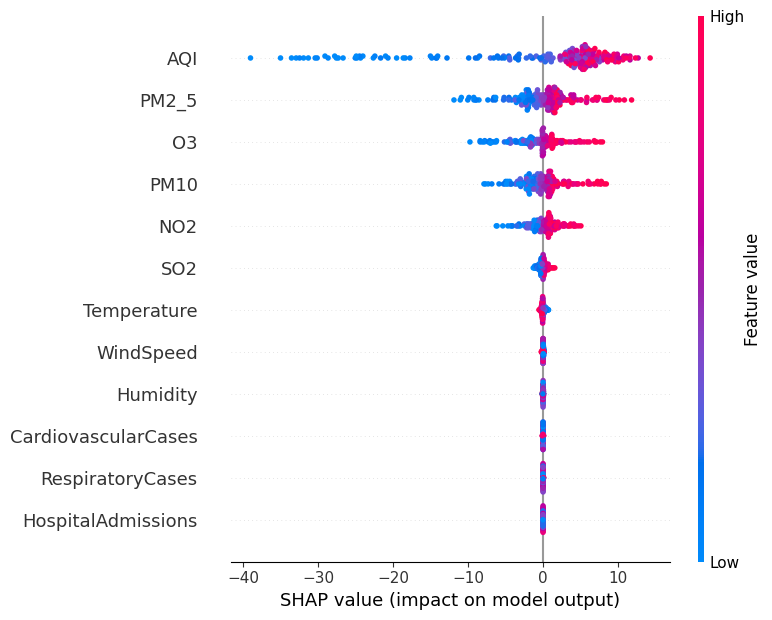

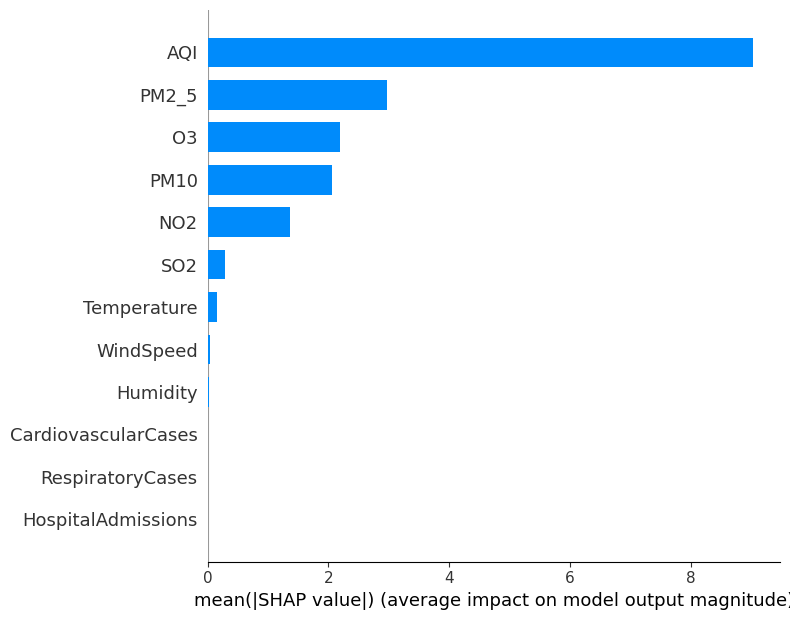

In [ ]:
try:
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_shap)

    shap.summary_plot(shap_values, X_shap)
    shap.summary_plot(shap_values, X_shap, plot_type="bar")

except Exception as e:
    print("SHAP direct nu a functionat:", e)
    print("Se foloseste KernelExplainer pe un subset.")

    X_background = X_train.sample(100, random_state=42)

    explainer = shap.KernelExplainer(best_model.predict, X_background)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap)
    shap.summary_plot(shap_values, X_shap, plot_type="bar")

## 11.3 Interpretarea globala SHAP

Analiza SHAP arata care caracteristici influenteaza cel mai mult predictia modelului.

Caracteristicile aflate in partea de sus a graficului sunt cele mai importante.

Valorile SHAP pozitive cresc predictia pentru `HealthImpactScore`.

Valorile SHAP negative scad predictia pentru `HealthImpactScore`.

## 11.4 Waterfall plot pentru o predictie locala

Waterfall plot-ul explica o singura predictie.

Acesta arata ce variabile au crescut sau au scazut valoarea prezisa pentru un exemplu concret.

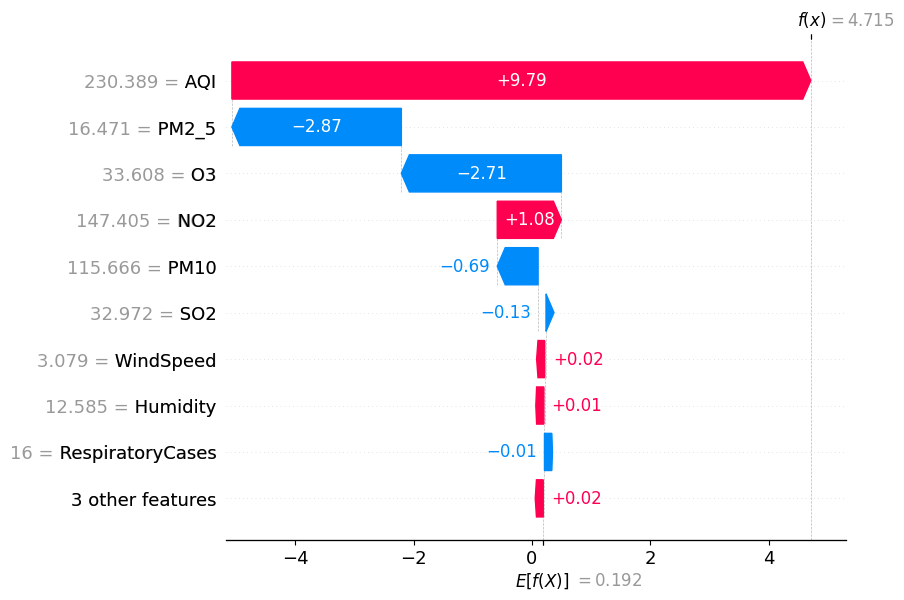

In [ ]:
try:
    shap.plots.waterfall(shap_values[0])
except Exception as e:
    print("Waterfall plot nu a functionat pentru aceasta forma a valorilor SHAP.")
    print(e)

## 11.5 SHAP scatter plot

Scatter plot-urile SHAP arata cum valorile unei caracteristici influenteaza predictia.

Aceste grafice sunt utile pentru a intelege daca valorile mari sau mici ale unei caracteristici cresc sau scad scorul prezis.

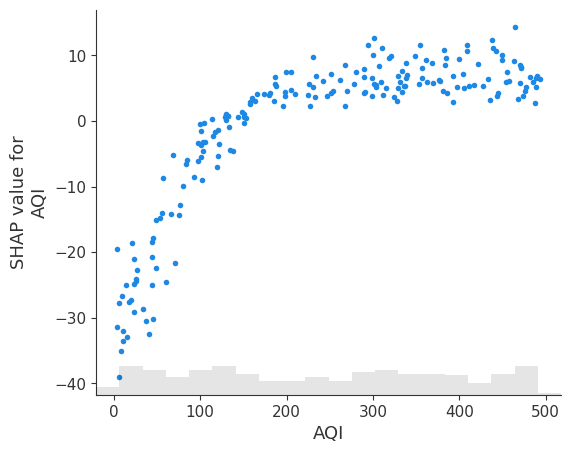

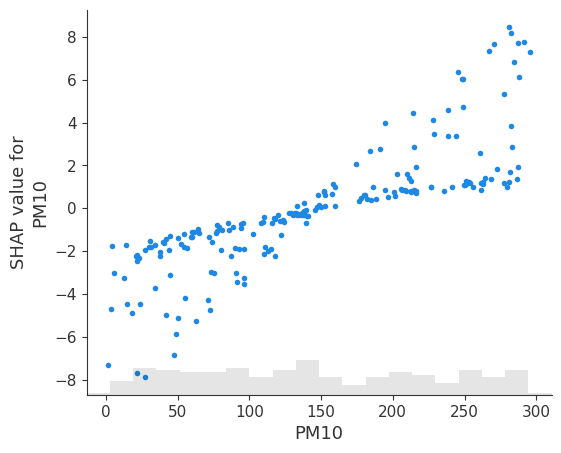

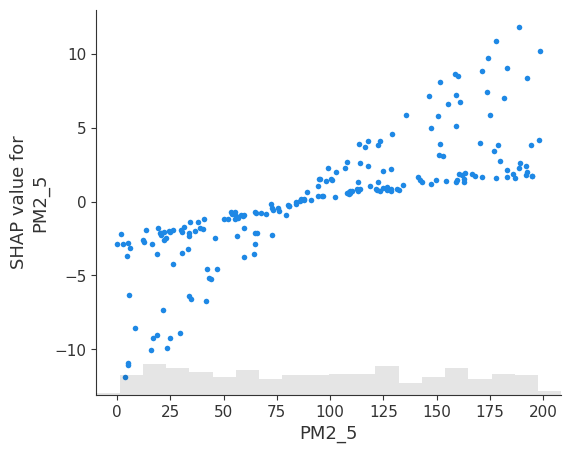

In [ ]:
try:
    top_features = X_shap.columns[:3]

    for feature in top_features:
        shap.plots.scatter(shap_values[:, feature])
except Exception as e:
    print("Scatter plot SHAP nu a functionat automat.")
    print(e)

## 11.6 Concluzie SHAP

Prin aceasta analiza putem identifica variabilele care au cea mai mare influenta asupra predictiei scorului `HealthImpactScore`.

Cele mai importante caracteristici trebuie interpretate in contextul problemei.

Daca poluantii sau indicatorii medicali apar printre cele mai importante variabile, acest lucru este logic, deoarece acestea sunt direct legate de calitatea aerului si impactul asupra sanatatii.

# 12. Concluzii finale

In acest notebook a fost analizata problema predictiei impactului calitatii aerului asupra sanatatii.

Variabila tinta a fost `HealthImpactScore`, iar scopul a fost construirea unor modele de regresie care sa prezica acest scor.

Au fost parcurse urmatoarele etape:
1. definirea problemei
2. analiza exploratorie a datelor
3. preprocesarea datelor
4. antrenarea mai multor modele de regresie
5. compararea modelelor folosind MSE, MAE, RMSE si R2
6. selectarea celor mai bune 5 modele
7. ajustarea hiperparametrilor
8. compararea modelelor optimizate
9. analiza predictiilor
10. curbele de invatare
11. interpretarea modelului folosind SHAP

In urma comparatiei, cel mai bun model a fost ales pe baza valorii R2 si a erorilor obtinute pe setul de test.

Modelele mai complexe pot surprinde relatii mai bune intre poluanti, conditii meteorologice si impactul asupra sanatatii.

Analiza SHAP a oferit o interpretare a caracteristicilor care influenteaza cel mai mult predictia.

In concluzie, regresia este potrivita pentru aceasta problema deoarece permite estimarea unui scor numeric de impact asupra sanatatii.